# Visualization and more data transformation.
Parts of this need to be added to the previous notebook.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Combine all daily datasets into one

In [10]:
import pandas as pd
import glob
import os

# 1. Define the directory path
path = 'daily_data' 

# 2. Find all CSV files in that folder
all_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Read each file and store in a list
df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    # Optional: Add a column to track which file the data came from
    df['source_file'] = os.path.basename(filename)
    df_list.append(df)

# 4. Combine everything into one master DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.head())

    timestamp ticker    open      high      low   close       volume  \
0  2021-04-28   AAPL  134.31  135.0200  133.080  133.58  107746597.0   
1  2021-04-29   AAPL  136.47  137.0700  132.450  133.48  151100953.0   
2  2021-04-30   AAPL  131.78  133.5600  131.065  131.46  109425466.0   
3  2021-05-03   AAPL  132.04  134.0700  131.830  132.54   75135100.0   
4  2021-05-04   AAPL  131.19  131.4899  126.700  127.85  137544918.0   

       vwap  transactions     source_file  
0  134.6526        783355  aapl_daily.csv  
1  134.1771       1059387  aapl_daily.csv  
2  132.1940        701292  aapl_daily.csv  
3  132.8122        580631  aapl_daily.csv  
4  127.9654       1182700  aapl_daily.csv  


In [11]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,source_file
0,2021-04-28,AAPL,134.310,135.0200,133.0800,133.58,1.077466e+08,134.6526,783355,aapl_daily.csv
1,2021-04-29,AAPL,136.470,137.0700,132.4500,133.48,1.511010e+08,134.1771,1059387,aapl_daily.csv
2,2021-04-30,AAPL,131.780,133.5600,131.0650,131.46,1.094255e+08,132.1940,701292,aapl_daily.csv
3,2021-05-03,AAPL,132.040,134.0700,131.8300,132.54,7.513510e+07,132.8122,580631,aapl_daily.csv
4,2021-05-04,AAPL,131.190,131.4899,126.7000,127.85,1.375449e+08,127.9654,1182700,aapl_daily.csv
...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-21,MRK,116.490,116.5250,111.9100,112.56,1.276666e+07,112.8961,151882,mrk_daily.csv
37646,2026-04-22,MRK,112.605,113.5100,111.5400,112.89,8.037515e+06,112.7810,101114,mrk_daily.csv
37647,2026-04-23,MRK,113.365,115.0199,113.1001,114.62,6.826250e+06,114.2806,93151,mrk_daily.csv
37648,2026-04-24,MRK,113.740,114.0300,111.5000,111.90,7.060016e+06,112.0417,93014,mrk_daily.csv


In [12]:
combined_df['ticker'].value_counts()

ticker
AAPL     1255
JNJ      1255
QQQ      1255
COST     1255
MSFT     1255
AMZN     1255
TSLA     1255
CVX      1255
DIA      1255
HD       1255
UNH      1255
PFE      1255
GE       1255
CAT      1255
GOOGL    1255
JPM      1255
SBUX     1255
NFLX     1255
SPY      1255
META     1255
UPS      1255
XOM      1255
BAC      1255
NVDA     1255
GS       1255
NKE      1255
MS       1255
WMT      1255
BA       1255
MRK      1255
Name: count, dtype: int64

In [13]:
df_daily_meta = pd.read_csv('daily_data/meta_daily.csv')
df_daily_meta

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-04-28,META,307.3600,310.92,305.3700,307.10,3.390721e+07,310.9193,398610
1,2021-04-29,META,330.1200,331.81,321.6100,329.51,5.642677e+07,326.9047,597569
2,2021-04-30,META,326.1435,329.82,324.5000,325.08,2.628242e+07,326.3254,272188
3,2021-05-03,META,326.1700,328.55,321.8400,322.58,1.871946e+07,324.2316,248771
4,2021-05-04,META,320.0250,322.19,313.1200,318.36,2.403256e+07,316.0934,291992
...,...,...,...,...,...,...,...,...,...
1250,2026-04-21,META,671.0000,676.20,667.3300,668.84,8.655071e+06,671.2143,271151
1251,2026-04-22,META,674.3550,678.38,669.7500,674.72,9.215604e+06,674.9735,276840
1252,2026-04-23,META,663.7000,669.56,653.0500,659.15,1.166698e+07,661.2060,362722
1253,2026-04-24,META,660.3200,680.67,653.8401,675.03,1.334963e+07,672.3935,367938


# FAANNG

In [22]:
daily_aapl = pd.read_csv('daily_data/daily_aapl.csv')
daily_amzn = pd.read_csv('daily_data/daily_amzn.csv')
daily_meta = pd.read_csv('daily_data/daily_meta.csv')
daily_nflx = pd.read_csv('daily_data/daily_nflx.csv')
daily_nvda = pd.read_csv('daily_data/daily_nvda.csv')
daily_googl = pd.read_csv('daily_data/daily_googl.csv')

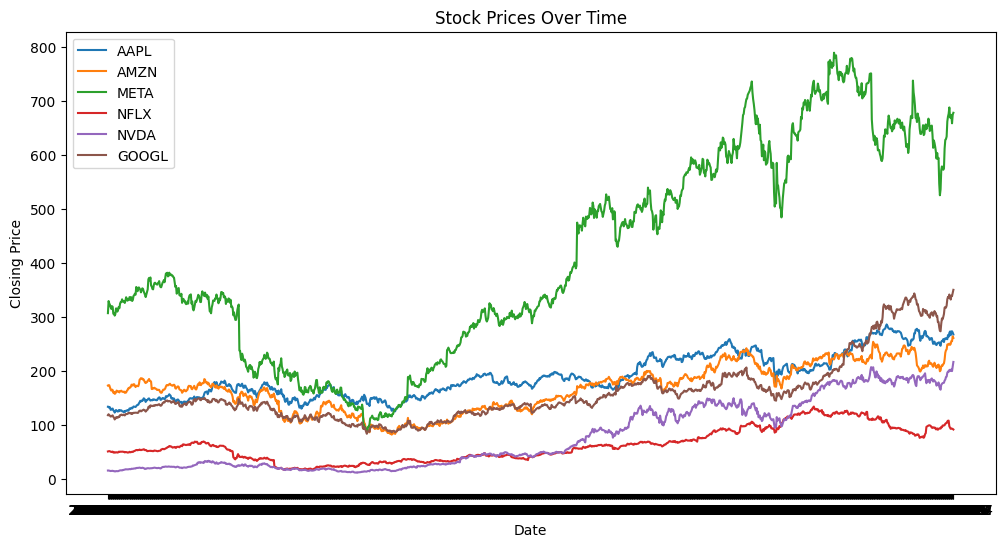

In [25]:
import matplotlib.pyplot as plt

# Make sure timestamps are datetime
for df in [aapl_daily, nvda_daily, amzn_daily, googl_daily]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_aapl['timestamp'], daily_aapl['close'], label='AAPL')
plt.plot(daily_amzn['timestamp'], daily_amzn['close'], label='AMZN')
plt.plot(daily_meta['timestamp'], daily_meta['close'], label='META')
plt.plot(daily_nflx['timestamp'], daily_nflx['close'], label='NFLX')
plt.plot(daily_nvda['timestamp'], daily_nvda['close'], label='NVDA')
plt.plot(daily_googl['timestamp'], daily_googl['close'], label='GOOGL')


plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Stock Prices Over Time')
plt.legend()

plt.show()

# FAANNG vs others
FAAANNG - Facebook (Meta), Apple, Amazon, Netflix, Nvidia, Google (Alphabet)

Can simplify this command

In [17]:
faanng_stocks = ['AAPL', 'NVDA', 'GOOGL', 'META', 'NFLX', 'AMZN']

df_faaanng = combined_df[combined_df['ticker'].isin(faanng_stocks)]
df_non_faaanng = combined_df[~combined_df['ticker'].isin(faanng_stocks)]

In [23]:
df_faaanng_avg = (
    df_faaanng
    .groupby('timestamp')
    .mean(numeric_only=True)
    .reset_index()
)

df_non_faaanng_avg = (
    df_non_faaanng
    .groupby('timestamp')
    .mean(numeric_only=True)
    .reset_index()
)

df_all_stocks_avg = (
    combined_df
    .groupby('timestamp')
    .mean(numeric_only=True)
    .reset_index()
)

In [27]:
df_all_stocks_avg

,timestamp,open,high,low,close,volume,vwap,transactions
0,2021-04-28,185.185970,186.418543,183.918073,184.915873,3.238404e+07,185.281477,183008.066667
1,2021-04-29,186.792460,188.270497,184.199043,186.816970,3.737268e+07,186.348633,218882.066667
2,2021-04-30,185.723873,187.530130,184.590793,185.944707,3.598528e+07,185.994730,180542.166667
3,2021-05-03,186.877053,188.682493,185.527367,186.970853,3.076111e+07,187.200180,163166.533333
4,2021-05-04,186.210620,187.664183,183.417057,186.268877,4.425088e+07,185.482037,229221.933333
...,...,...,...,...,...,...,...,...
1250,2026-04-21,337.174667,340.093330,332.112370,334.163667,2.371945e+07,335.502257,370443.733333
1251,2026-04-22,336.781000,339.290280,333.773213,336.903333,2.089865e+07,336.628893,335629.466667
1252,2026-04-23,336.287000,340.062953,332.684970,336.681000,2.253782e+07,336.803223,371560.500000
1253,2026-04-24,336.969500,340.014801,333.840563,337.735333,2.519192e+07,337.138733,364880.533333


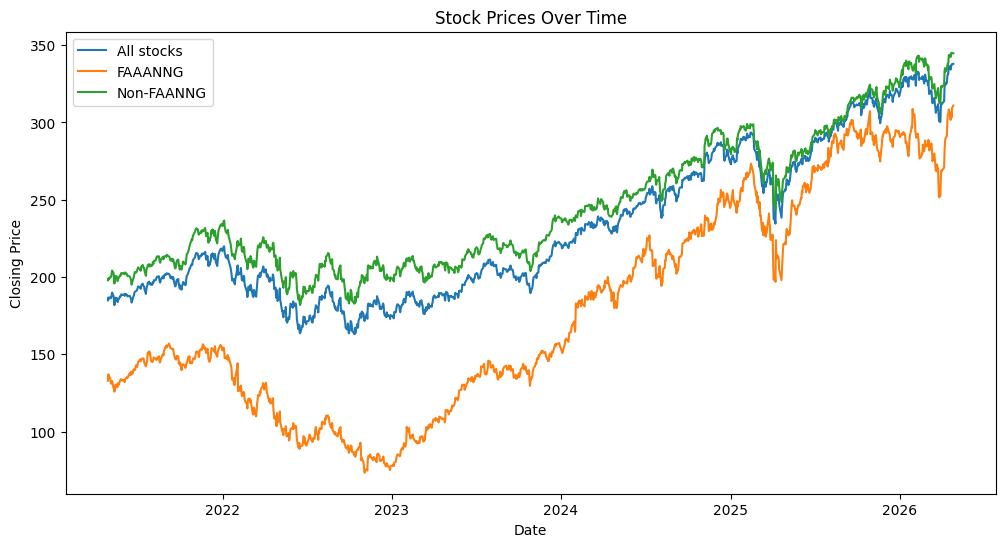

In [28]:
import matplotlib.pyplot as plt

# Make sure timestamps are datetime
for df in [df_faaanng_avg, df_non_faaanng_avg, df_all_stocks_avg]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(df_all_stocks_avg['timestamp'], df_all_stocks_avg['close'], label='All stocks')
plt.plot(df_faaanng_avg['timestamp'], df_faaanng_avg['close'], label='FAAANNG')
plt.plot(df_non_faaanng_avg['timestamp'], df_non_faaanng_avg['close'], label='Non-FAANNG')


plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Stock Prices Over Time')
plt.legend()

plt.show()

# Apple - SMA (temporary, will soon add this step to previous notebooks to avoid having to do it manually every time)


In [27]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387
...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032


In [36]:
aapl_daily['sma20'] = aapl_daily['close'].rolling(window=20).mean()
aapl_daily['sma50'] = aapl_daily['close'].rolling(window=50).mean()
aapl_daily['sma100'] = aapl_daily['close'].rolling(window=100).mean()
aapl_daily['sma150'] = aapl_daily['close'].rolling(window=150).mean()

aapl_daily

aapl_daily_with_sma = aapl_daily.dropna()
aapl_daily_with_sma

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150
149,2021-11-23,AAPL,161.120,161.800,159.0601,161.41,9.602290e+07,160.3405,712377,152.3150,147.8676,147.9696,141.806067
150,2021-11-24,AAPL,160.750,162.140,159.6400,161.94,6.926362e+07,161.1093,505241,152.9695,148.1258,148.1688,141.990200
151,2021-11-26,AAPL,159.565,160.450,156.3600,156.81,7.694075e+07,157.8439,666767,153.1815,148.2862,148.2912,142.137467
152,2021-11-29,AAPL,159.370,161.190,158.7901,160.24,8.849822e+07,160.1333,663948,153.7035,148.5698,148.4612,142.309800
153,2021-11-30,AAPL,159.985,165.520,159.9200,165.30,1.739581e+08,163.7750,1139625,154.5205,149.0170,148.6631,142.521267
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.160,266.560,257.8100,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533
1250,2026-04-16,AAPL,266.800,267.160,261.2700,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600
1251,2026-04-17,AAPL,266.960,272.300,266.7200,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600
1252,2026-04-20,AAPL,270.330,274.275,270.2900,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467


/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_92698/2411933263.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aapl_daily_with_sma['Date'] = pd.to_datetime(aapl_daily_with_sma['timestamp'])


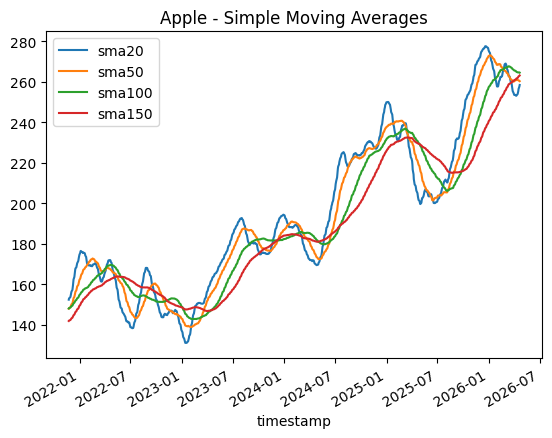

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the date column is a datetime object
aapl_daily_with_sma['Date'] = pd.to_datetime(aapl_daily_with_sma['timestamp'])

# 2. Plot all 4 columns on the same chart using the Date column as the x-axis
aapl_daily_with_sma.plot(x='timestamp', y=['sma20', 'sma50', 'sma100', 'sma150'])
plt.title('Apple - Simple Moving Averages')
plt.show()

# Data Transformation

In [44]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,NaN,NaN,NaN
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,NaN,NaN,NaN
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,NaN,NaN,NaN
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,NaN,NaN,NaN
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467


In [47]:
aapl_daily['close_daily_change'] = aapl_daily['close'].diff()
aapl_daily['close_daily_change_abs'] = aapl_daily['close_daily_change'].abs()

In [48]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150,close_vs_prev,close_daily_change,close_daily_change_abs
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,NaN,NaN,NaN,0.40,0.40,0.40
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,NaN,NaN,NaN,-0.33,-0.33,0.33
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,NaN,NaN,NaN,-0.81,-0.81,0.81
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,NaN,NaN,NaN,-0.10,-0.10,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533,7.60,7.60,7.60
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600,-3.03,-3.03,3.03
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600,6.83,6.83,6.83
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467,2.82,2.82,2.82


In [49]:
# Total absolute daily change across all - Rough indicator of volatility?
aapl_daily['close_daily_change_abs'].sum()

np.float64(2836.17)

In [53]:
# Average daily change (non-absolute)
aapl_daily['close_daily_change'].mean()

np.float64(0.10522745411013569)

In [54]:
# Average adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_change'].mean()) * 1254

np.float64(131.95522745411014)

In [57]:
# What was the total change from beginning to end of the dataset?
aapl_daily['close'].iloc[-1] - aapl_daily['close'].iloc[0]

np.float64(131.85000000000002)

In [55]:
# Median daily change (non-absolute)
aapl_daily['close_daily_change'].median()

np.float64(0.17000000000001592)

In [56]:
# Median adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_change'].median()) * 1254

np.float64(213.18000000001996)

Should all of the above be instead rendered as percentages? Probably so considering assignment asks for those.

In [58]:
# Percentage change ( (Value_Curr - Value_Prev) / Value_Prev )
aapl_daily['close_daily_pct_change'] = aapl_daily['close'].pct_change()
aapl_daily['close_daily_abs_pct_change'] = aapl_daily['close_daily_pct_change'].abs()

In [63]:
# Average pct daily change (non-absolute)
aapl_daily['close_daily_pct_change'].mean()

np.float64(0.0006949308393557564)

In [65]:
# Average pct daily change adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_pct_change'].mean()) * 1254

np.float64(0.8714432725521185)

In [67]:
# Percentage change from beginning to end
pct_change = (aapl_daily['close'].iloc[-1] / aapl_daily['close'].iloc[0] - 1) * 100
pct_change

np.float64(98.16110780226327)

# Columns for daily changes 2,3,4,5,6 pct

In [73]:
aapl_daily['pct_dly_change_2'] = (aapl_daily['close_daily_pct_change'] >= 2).astype(int)
aapl_daily['pct_dly_change_3'] = (aapl_daily['close_daily_pct_change'] >= 3).astype(int)
aapl_daily['pct_dly_change_4'] = (aapl_daily['close_daily_pct_change'] >= 4).astype(int)
aapl_daily['pct_dly_change_5'] = (aapl_daily['close_daily_pct_change'] >= 5).astype(int)
aapl_daily['pct_dly_change_6'] = (aapl_daily['close_daily_pct_change'] >= 6).astype(int)

# Create binary column: 1 if next row is > 0, else 0
#df['next_pos'] = (df['value'].shift(-1) > 0).astype(int)

aapl_daily['next_day_pos'] = (aapl_daily['close_daily_change'].shift(-1) > 0).astype(int)
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,...,close_daily_change,close_daily_change_abs,close_daily_pct_change,close_daily_abs_pct_change,pct_dly_change_2,pct_dly_change_3,pct_dly_change_4,pct_dly_change_5,pct_dly_change_6,next_day_pos
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,...,NaN,NaN,NaN,NaN,0,0,0,0,0,1
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,...,0.40,0.40,0.002978,0.002978,0,0,0,0,0,0
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,...,-0.33,0.33,-0.002450,0.002450,0,0,0,0,0,0
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,...,-0.81,0.81,-0.006027,0.006027,0,0,0,0,0,0
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,...,-0.10,0.10,-0.000749,0.000749,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,...,7.60,7.60,0.029363,0.029363,0,0,0,0,0,0
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,...,-3.03,3.03,-0.011373,0.011373,0,0,0,0,0,1
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,...,6.83,6.83,0.025930,0.025930,0,0,0,0,0,1
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,...,2.82,2.82,0.010436,0.010436,0,0,0,0,0,0


In [77]:
aapl_daily['pct_dly_change_2'].value_counts()

pct_dly_change_2
0    1254
Name: count, dtype: int64

Weird, seems AAPL never had a signed daily change of at least 2%. Is AAPL just an unusually stable stock or do I need to find another source? What are these numbers anyway, seem a lot lower than the ones I see.

Also need to add, as a more robust indicator of volatility, daily change (and abs change) vs average of all stocks.

Measure sums of daily changes and daily absolute changes against the overall change during the entire span.

Would it also be useful to have yearly and monthly changes?

In [ ]:
# Percentage change ( (Value_Curr - Value_Prev) / Value_Prev )
#df['Percent_Change'] = df['Value'].pct_change()

# Old

In [2]:
# Apple
aapl_daily = pd.read_csv('datasets/aapl_daily.csv')
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387
...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032


In [ ]:
aapl_daily

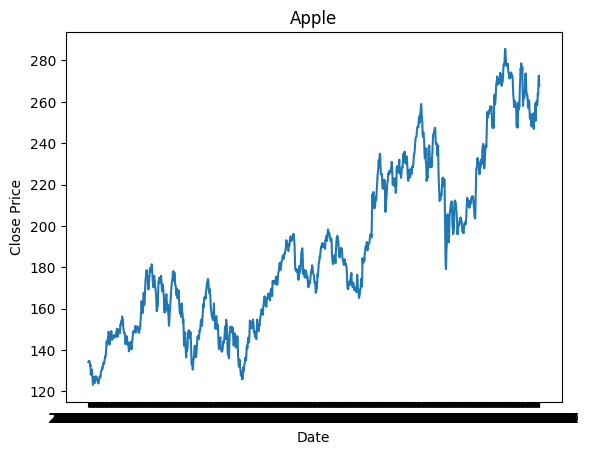

In [7]:
plt.plot(aapl_daily['timestamp'], aapl_daily['vwap'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Apple')
plt.show()